### Review of Convolutional Neural Networks (CNNs)

Convolutional Neural Networks (CNNs) are a class of deep learning models that are particularly effective for processing data with a grid-like topology, such as images. They are designed to automatically and adaptively learn spatial hierarchies of features from input data, making them ideal for tasks like image recognition, object detection, and segmentation.

#### Key Components of CNNs:
1. **Convolutional Layers**: These layers apply a set of learnable filters (kernels) to the input data, producing feature maps that capture various features such as edges, textures, and patterns.
2. **Pooling Layers**: These layers reduce the spatial dimensions of the feature maps, helping to decrease computational load and control overfitting. Common pooling operations include max pooling and average pooling.
3. **Fully Connected Layers**: These layers are typically used at the end of the network to perform classification or regression tasks based on the features extracted by the convolutional and pooling layers.
4. **Activation Functions**: Non-linear activation functions like ReLU (Rectified Linear Unit) are applied after convolutional and fully connected layers to introduce non-linearity into the model, allowing it to learn complex patterns.

In [19]:
import tensorflow as tf
import matplotlib.pyplot as plt

plt.rc('image', cmap='gray')
plt.rc('figure', autolayout=True)

Load the image dataset and preprocess it for training the CNN model. This typically involves resizing the images, normalizing pixel values, and splitting the dataset into training and testing sets.

In this code, we will allow the user to upload an image and then preprocess it for use in a CNN model. The preprocessing steps include resizing the image to a standard size, normalizing pixel values to the range [0, 1], and preparing the image for input into the model.

To upload an image, we can use the following code snippet. Download Colab and run the code to upload an image from your local machine

Original Image Shape: (300, 300, 1)


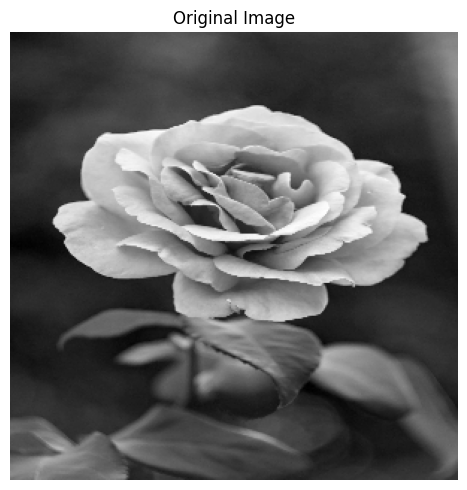

In [20]:
# Upload an image
#from google.colab import files
# uploaded = files.upload()

# Get the path of the uploaded image
# image_path = list(uploaded.keys())[0]
image_path = "pink_flower.jpg" 

image = tf.io.read_file(image_path)
image = tf.io.decode_jpeg(image, channels=1)  
image = tf.image.resize(image, [300, 300])
image = tf.image.convert_image_dtype(image, tf.float32)

print("Original Image Shape:", image.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(image))
plt.title("Original Image")
plt.axis('off')
plt.show()

# Add batch dimension
image = tf.expand_dims(image, axis=0)

Define detection layers and build the CNN model architecture. This may include multiple convolutional and pooling layers, followed by fully connected layers for classification.

In [21]:
kernel = tf.constant([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=tf.float32)

kernel = tf.reshape(kernel, [3, 3, 1, 1])

The convolutional layers will learn to detect features in the images, while the pooling layers will help to reduce the spatial dimensions and prevent overfitting. Finally, the fully connected layers will use the extracted features to make predictions about the classes of the images.

After Convolution Shape: (1, 300, 300, 1)


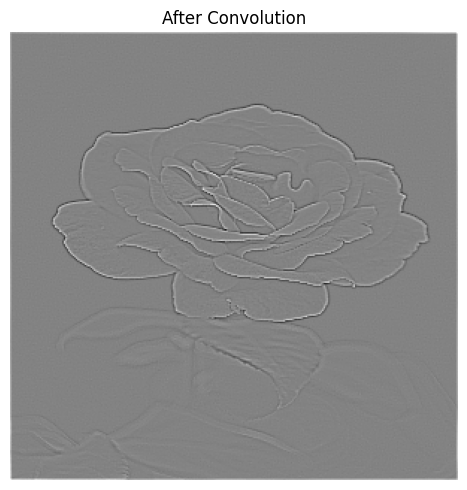

In [22]:
conv_output = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=1,
    padding='SAME'
)

print("After Convolution Shape:", conv_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(conv_output))
plt.title("After Convolution")
plt.axis('off')
plt.show()

Applying the ReLU activation function after each convolutional layer will help the model to learn non-linear relationships in the data, which is crucial for achieving high performance in image classification tasks.

After ReLU Shape: (1, 300, 300, 1)


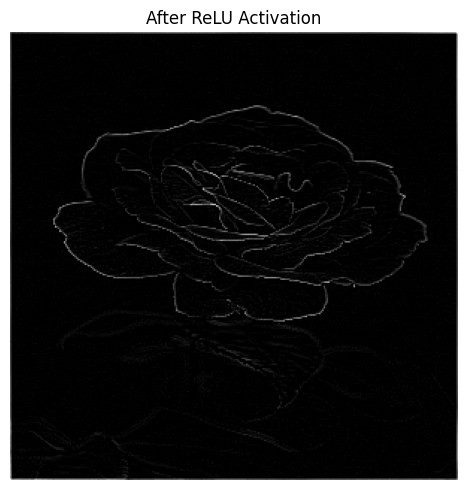

In [23]:
relu_output = tf.nn.relu(conv_output)

print("After ReLU Shape:", relu_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(relu_output))
plt.title("After ReLU Activation")
plt.axis('off')
plt.show()

Apply Max Pooling after convolutional layers to reduce the spatial dimensions of the feature maps, which helps to decrease computational load and control overfitting.

After Pooling Shape: (1, 150, 150, 1)


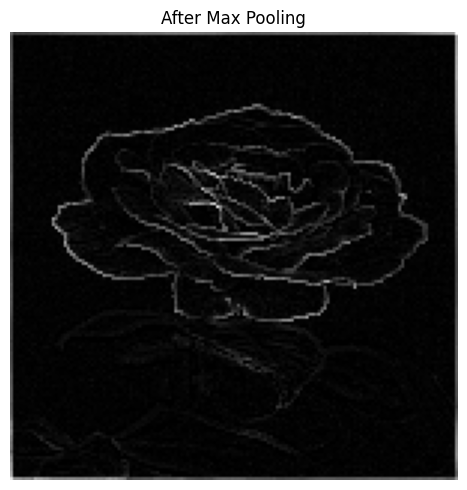

In [24]:
pool_output = tf.nn.max_pool2d(
    input=relu_output,
    ksize=2,
    strides=2,
    padding='SAME'
)

print("After Pooling Shape:", pool_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(pool_output))
plt.title("After Max Pooling")
plt.axis('off')
plt.show()

The flattening layer will convert the 2D feature maps into a 1D vector, which can then be fed into the fully connected layers for classification.

In [25]:
flatten_layer = tf.keras.layers.Flatten()
flatten_output = flatten_layer(pool_output)

print("After Flatten Shape:", flatten_output.shape)

print("First 20 Flattened Values:")
print(flatten_output.numpy()[0][:20])

After Flatten Shape: (1, 22500)
First 20 Flattened Values:
[277.26996 166.59009 192.84381 183.27834 192.17448 181.31505 184.63452
 190.75381 195.83368 198.49648 200.71997 199.2858  206.65666 231.87137
 214.1286  222.45197 229.96349 227.43    246.23868 246.05856]


The fully connected layers will use the features extracted by the convolutional and pooling layers to make predictions about the classes of the images. The final output layer will typically use a softmax activation function for multi-class classification tasks, providing probabilities for each class.

In [26]:
dense_layer = tf.keras.layers.Dense(
    units=64,         
    activation='relu' 
)

dense_output = dense_layer(flatten_output)

print("After Fully Connected Layer Shape:", dense_output.shape)

After Fully Connected Layer Shape: (1, 64)


CNNs can contribute to Speech Emotion Recognition (SER) by effectively extracting features from audio spectrograms, which are visual representations of the frequency content of audio signals over time. By treating these spectrograms as images, CNNs can learn to identify patterns and features that correspond to different emotional states in speech.